# Econ 8208 Assignment 3

- Author: Yuxuan Zhao
- Date: 2026-03-27

In [1]:
using LinearAlgebra
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools


# Local LQ Approximation

We are given

- a return function $r(x,u)$, where $x \in \mathbb{R}^n$ and $u \in \mathbb{R}^m$,
- a state transition function $g(x,u)$,
- a steady state $(\bar x, \bar u)$.

We want to construct the matrices for the standard local LQ approximation:
$$
\begin{aligned}
r(x,u) &\approx r(\bar x,\bar u) + \hat x' Q \hat x + 2 \hat x' W \hat u + \hat u' R \hat u, \\
\hat x_{t+1} &= A \hat x_t + B \hat u_t, \\
\hat x &= x-\bar x, \quad \hat u = u-\bar u. \\
\end{aligned}
$$


We need to compute the following matrices:
$$
Q = \frac{1}{2} r_{xx}(\bar x,\bar u), \qquad
W = \frac{1}{2} r_{xu}(\bar x,\bar u), \qquad
R = \frac{1}{2} r_{uu}(\bar x,\bar u),
$$
and
$$
A = g_x(\bar x,\bar u), \qquad B = g_u(\bar x,\bar u).
$$



## HW 3

We are given the matrices from the local LQ approximation:
$$
Q, \quad W, \quad R, \quad A, \quad B,
$$
together with the discount factor $\beta$.

The problem is to solve the infinite-horizon LQ problem:
$$
\hat V(\hat x) = \max_{\{\hat u_t\}} \sum_{t=0}^{\infty} \beta^t
\left(
\hat x_t' Q \hat x_t + 2 \hat x_t' W \hat u_t + \hat u_t' R \hat u_t
\right)
$$
subject to
$$
\hat x_{t+1} = A \hat x_t + B \hat u_t.
$$

Because the return is quadratic and the law of motion is linear, we guess that the value function takes the quadratic form
$$
\hat V(\hat x) = \hat x' P \hat x.
$$

Substituting this guess into the Bellman equation and taking the first-order condition with respect to $\hat u$, we obtain the policy rule
$$
\hat u = -F \hat x,
$$
where
$$
F = \left(R + \beta B' P B\right)^{-1}\left(W' + \beta B' P A\right).
$$

Substituting the policy rule back into the Bellman equation gives the Riccati equation:
$$
P
=
Q - F'W' - WF + F'RF + \beta (A - BF)' P (A - BF).
$$

We solve this equation by fixed-point iteration.

### Pseudocode

**Input:** $Q, W, R, A, B, \beta$, tol, max\_iter, P^0, $h$
**Output:** $F, P$, number of iterations, convergence status

**Algorithm:**

1. Initialize $P$ as a zero matrix.
2. Compute
   $$
   H_{uu} = R + \beta B' P B,
   \qquad
   H_{ux} = W' + \beta B' P A.
   $$
3. Compute
   $$
   F = H_{uu}^{-1} H_{ux}.
   $$
4. Compute the closed-loop transition matrix
   $$
   A_{cl} = A - BF.
   $$
5. Update
   $$
   P_{\text{new}}
   =
   Q - F'W' - WF + F'RF + \beta A_{cl}' P A_{cl}.
   $$
6. Stop if
   $$
   \|P_{\text{new}} - P\| < \text{tol}.
   $$
   return $F, P$, number of iterations, and convergence status.
7. If not converged, set $P = P_{\text{new}}$ and repeat steps 2--6.
8. If the maximum number of iterations is reached and $\|P_{\text{new}} - P\| \ge \text{tol}$, return the last computed $F, P$, number of iterations, and convergence status as False.

### Example: Deterministic Growth Model

Use a simple economic example to test the implementation code, we consider the standard deterministic growth model. 

The planner's problem is:
$$
\begin{aligned}
\max_{\{i_t\}} &\sum_{t=0}^{\infty} \beta^t \log(c_t) \quad \text{s. t.} \\
c_t + i_t &= k_t^\alpha + (1-\delta)k_t, \\
k_{t+1} &= (1-\delta)k_t + i_t
\end{aligned}
$$

which can be rewritten as
$$
\begin{aligned}
\max_{\{i_t\}} \sum_{t=0}^{\infty} \beta^t& \log\!\left(k_t^\alpha + (1-\delta)k_t - i_t\right) \quad \text{s. t.} \\
k_{t+1} &= (1-\delta)k_t + i_t.
\end{aligned}
$$


### Steady State

In the steady state, capital and investment are constant, so
$$
\bar i = \delta \bar k.
$$

The Euler equation implies
$$
1 = \beta \left(\alpha \bar k^{\alpha-1} + 1-\delta \right).
$$

Solving for the steady-state capital gives
$$
\bar k
=
\left(
\frac{\alpha}{1/\beta - 1 + \delta}
\right)^{\frac{1}{1-\alpha}}.
$$

Then steady-state investment and consumption are
$$
\bar i = \delta \bar k,
\qquad
\bar c = \bar k^\alpha + (1-\delta)\bar k - \bar i.
$$

We let:
$$
x = k, \qquad u = i
$$
Then we have:
$$
r(x,u) = \log\!\left(x^\alpha + (1-\delta)x - u\right), \\
g(x,u) = (1-\delta)x + u. \\
\bar x = \bar k \\
\bar u = \bar i = \delta \bar k.
$$

We can then evaluate the matrices $Q, W, R, A, B$ at $(\bar x, \bar u)$ and use them as inputs for the Riccati solver.


In [3]:
# -------------------------------------------------------
# Example: deterministic growth model
# Variables:
#   state   x = capital k
#   control u = investment i
# Functions:
#   return function: r(x, u) = log(c) where c = x[1]^α - u[1] + (1.0 - δ) * x[1]
#   transition function: g(x, u) = (1.0 - δ) * x[1] + u[1]
# Steady state: 
#   kbar = (α / (1.0 / β - 1.0 + δ))^(1.0 / (1.0 - α))
#   ibar = δ * kbar
#   cbar = kbar^α + (1.0 - δ) * kbar - ibar
# -------------------------------------------------------

α = 0.33
β = 0.96
δ = 0.10
h = 1e-6

# Return function and transition function
r(x, u) = log(x[1]^α + (1.0 - δ) * x[1] - u[1])
g(x, u) = [(1.0 - δ) * x[1] + u[1]]

# Steady state
kbar = (α / (1.0 / β - 1.0 + δ))^(1.0 / (1.0 - α))
ibar = δ * kbar
cbar = kbar^α + (1.0 - δ) * kbar - ibar

xbar = [kbar]
ubar = [ibar]

println("steady-state capital = ", kbar)
println("steady-state investment = ", ibar)
println("steady-state consumption = ", cbar)

# Local LQ approximation
Q, W, R, A, B = tools.lq_approximation(r, g, xbar, ubar; h=h)

println("Q = ")
println(Q)

println("W = ")
println(W)

println("R = ")
println(R)

println("A = ")
println(A)

println("B = ")
println(B)

# Solve Riccati equation
F, P = tools.solve_riccati(Q, W, R, A, B, β)

println("F = ")
println(F)

println("P = ")
println(P)


steady-state capital = 3.5328789171564186
steady-state investment = 0.3532878917156419
steady-state consumption = 4.342943072908447
Q = 
[-0.03197442310920451;;]
W = 
[0.02758904216193514;;]
R = 
[-0.026423307986078726;;]
A = 
[0.8999999998593466;;]
B = 
[0.9999999999177334;;]
F = 
[0.38634208504376016;;]
P = 
[-0.07665096143661614;;]


Note that, under the current specification
$$
r(x,u) = \log(x^\alpha + (1-\delta)x - u),
\qquad
g(x,u) = (1-\delta)x + u,
$$
the implied steady-state consumption is
$$
\bar c = \bar k^\alpha + (1-\delta)\bar k - \bar i.
$$
Since $\bar i = \delta \bar k$, this becomes
$$
\bar c = \bar k^\alpha + (1-2\delta)\bar k.
$$


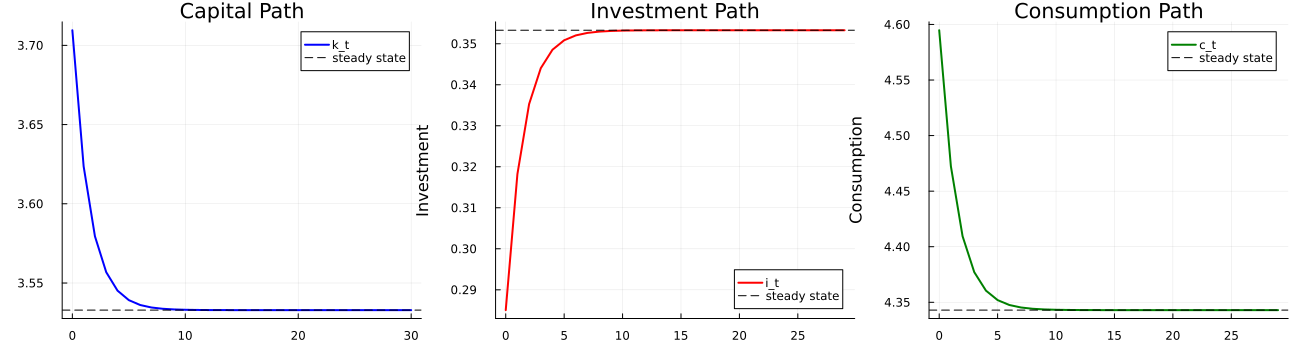

In [4]:
using Plots

# -------------------------------------------------------
# Simulate the LQ policy path
# Initial condition: K0 = 1.05 * Kbar
# Policy rule: \hat i_t = -F \hat k_t
# Then recover the level paths for k_t, i_t, and c_t
# -------------------------------------------------------

T = 30

# Initial capital level
k0 = 1.05 * kbar
khat0 = k0 - kbar

# Extract scalar values from 1x1 matrices
A1 = A[1, 1]
B1 = B[1, 1]
F1 = F[1, 1]

# Closed-loop coefficient
Acl = A1 - B1 * F1

# Allocate arrays
khat = zeros(T + 1)
ihat = zeros(T)
k = zeros(T + 1)
i = zeros(T)
c = zeros(T)

# Set initial condition
khat[1] = khat0
k[1] = k0

# Simulate the path
for t in 1:T
    ihat[t] = -F1 * khat[t]
    khat[t + 1] = Acl * khat[t]

    i[t] = ibar + ihat[t]
    k[t + 1] = kbar + khat[t + 1]

    # Recover consumption from the resource constraint
    c[t] = k[t]^α + (1.0 - δ) * k[t] - i[t]
end

# Time indices
tk = 0:T
ti = 0:(T - 1)

# -------------------------------------------------------
# Plot capital path with steady-state line
# -------------------------------------------------------
p1 = plot(
    tk, k,
    label = "k_t",
    linewidth = 2,
    color = :blue,
    xlabel = "t",
    ylabel = "Capital",
    title = "Capital Path"
)

hline!(p1, [kbar], linestyle = :dash, color = :black, label = "steady state")

# -------------------------------------------------------
# Plot investment path with steady-state line
# -------------------------------------------------------
p2 = plot(
    ti, i,
    label = "i_t",
    linewidth = 2,
    color = :red,
    xlabel = "t",
    ylabel = "Investment",
    title = "Investment Path"
)

hline!(p2, [ibar], linestyle = :dash, color = :black, label = "steady state")

# -------------------------------------------------------
# Plot consumption path with steady-state line
# -------------------------------------------------------
p3 = plot(
    ti, c,
    label = "c_t",
    linewidth = 2,
    color = :green,
    xlabel = "t",
    ylabel = "Consumption",
    title = "Consumption Path"
)

hline!(p3, [cbar], linestyle = :dash, color = :black, label = "steady state")

plot(p1, p2, p3, layout = (1, 3), size = (1300, 350))
